In [1]:
%run src/donnees.py

# df_caract_recoder
# df_lieux_recoder
# df_vehicule_recoder
# df_usager_recoder
# df_final

/home/onyxia/work/Projet_pythonDS/src/donnees.py:25: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_lieux_23 = pd.read_csv(url_lieux_23, sep=';', encoding='UTF-8')
/home/onyxia/work/Projet_pythonDS/src/donnees.py:26: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_lieux_22 = pd.read_csv(url_lieux_22, sep=';', encoding='UTF-8')


# Modelisation :
- classification avec gravité en variables catégorielle : 1 = Indemne, 2 = Blessé léger, 3 = Blessé hospitalisé, 4 = Tué
- Random Forest et/ou Regression logistique
- Facteurs clés : type de véhicule, ancienneté du véhicule, choc avant / arrière / latéral, âge, sexe, port de la ceinture / casque, alcoolémie, météo, luminosité, état de la chaussée, type de route (autoroute, nationale, départementale), zone (urbaine / rurale), département, zone accidentogène (a rajouter ?), heure, saison (a rajouter ?)
- A faire : one hot encoding, gérer les valeurs manquantes 

In [ ]:
df_final["grav"].unique()

In [ ]:
df_final.columns

## I - Random Forest

In [2]:
grav_dict = {
    "Indemne":1,
    "Tué":4,
    "Blessé hospitalisé":3,
    "Blessé léger":2
}
df_final = recodage(df_final, {"grav": grav_dict})
df_final = df_final.dropna(subset=['grav'])

In [ ]:
df_final.info()

In [3]:
y = df_final["grav"].astype(int).astype(str)
X = df_final[[
    "mois", "an", "lum", "dep", "circ", "surf", "vma", "catv", "obs",
    "obsm", "choc", "sexe", "trajet", "secu1", "age"
]]
X["an"] = X["an"].astype(str)

/tmp/ipykernel_2851/842654536.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["an"] = X["an"].astype(str)


### Vérification des valeurs manquantes - A FAIRE

In [ ]:
X.info()

### Encodage des variables explicatives 

In [4]:
import pandas as pd

X_encoded = pd.get_dummies(X, drop_first=True)

# Train, test 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=66, stratify=y
)
# startify pour les classes déséquilibré 


In [ ]:
X_train

### Entrainement du modèle 

A faire : 
- optimisation des paramètres 
- penalisation en fonction des classes (pas bcp de tué)
- gestion des non renseigné et -1


In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Evaluation et importance des facteurs 

In [6]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))




              precision    recall  f1-score   support

           1       0.73      0.82      0.77     31990
           2       0.70      0.52      0.60     29859
           3       0.42      0.54      0.47     11531
           4       0.26      0.30      0.28      2076

    accuracy                           0.64     75456
   macro avg       0.53      0.54      0.53     75456
weighted avg       0.66      0.64      0.64     75456

[[26275  3485  1970   260]
 [ 8113 15540  5687   519]
 [ 1408  2909  6214  1000]
 [  225   260   974   617]]


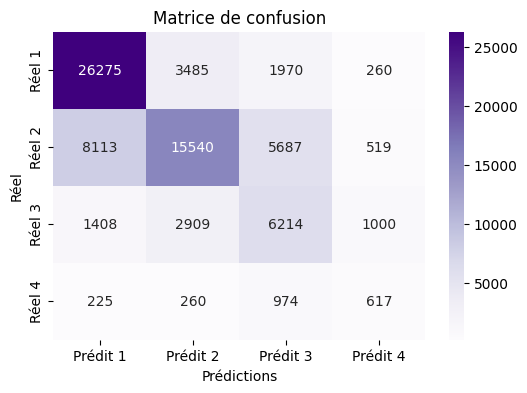

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# y_true = vraies classes
# y_pred = classes prédites

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Prédit 1', 'Prédit 2','Prédit 3', 'Prédit 4'],
            yticklabels=['Réel 1', 'Réel 2', 'Réel 3', 'Réel 4'])
plt.xlabel('Prédictions')
plt.ylabel('Réel')
plt.title('Matrice de confusion')
plt.show()


In [ ]:
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

for i in indices[:20]:
    print(f"{X_encoded.columns[i]} : {importances[i]:.4f}")

In [ ]:
import numpy as np

cm = confusion_matrix(y_test, y_pred)
cm_norm = cm / np.sum(cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Purples',
            xticklabels=['Prédit 1', 'Prédit 2','Prédit 3', 'Prédit 4'],
            yticklabels=['Réel 1', 'Réel 2', 'Réel 3', 'Réel 4'])
plt.xlabel('Prédictions')
plt.ylabel('Réel')
plt.title('Matrice de confusion normalisée')
plt.show()


les classes 1 et 2 sont bien prédites, pour les classes 3 et 4 bcp moins debonnes prédictions, cela est du au fait que les données comporte moins d'accidnet comportant ces gravités de blessures, le 3 et 4 sont tué et blessures hospitalisé.
Sauf que nous on voudrait notamment prédire les tués pour voir ce qui est le plus dangereux ! Il va falloir donc rajouter des pénalisation :

In [23]:
from sklearn.ensemble import RandomForestClassifier

poids = {
    "1": 1,   # indemne
    "2": 1.07,   # blessé léger
    "3": 2.77,   # blessé hospitalisé
    "4": 15.4   # tué
}

rf2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight=poids,
    random_state=42,
    n_jobs=-1
)

rf2.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
y_pred2 = rf2.predict(X_test)

print(classification_report(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))



              precision    recall  f1-score   support

           1       0.73      0.82      0.77     31990
           2       0.70      0.52      0.60     29859
           3       0.42      0.54      0.47     11531
           4       0.26      0.30      0.28      2076

    accuracy                           0.64     75456
   macro avg       0.53      0.54      0.53     75456
weighted avg       0.66      0.64      0.64     75456

[[26222  3561  1944   263]
 [ 8110 15547  5652   550]
 [ 1414  2933  6202   982]
 [  231   265   960   620]]


In [26]:
!pip install imblearn
from imblearn.ensemble import BalancedRandomForestClassifier

brf = BalancedRandomForestClassifier(
    n_estimators=400,
    sampling_strategy="auto",
    random_state=42,
    n_jobs=-1
)

brf.fit(X_train, y_train)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [imblearn]1/3 [imbalanced-learn]


,n_estimators,400
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [27]:
y_pred_brf = brf.predict(X_test)

print(classification_report(y_test, y_pred_brf))
print(confusion_matrix(y_test, y_pred_brf))



              precision    recall  f1-score   support

           1       0.73      0.80      0.76     31990
           2       0.72      0.45      0.55     29859
           3       0.39      0.37      0.38     11531
           4       0.13      0.67      0.21      2076

    accuracy                           0.59     75456
   macro avg       0.49      0.57      0.48     75456
weighted avg       0.66      0.59      0.61     75456

[[25608  3025  1470  1887]
 [ 8071 13361  4784  3643]
 [ 1182  2127  4258  3964]
 [  151   147   391  1387]]


### GridSearchCV


In [9]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [
        {1:1, 2:1, 3:1, 4:5},
        {1:1, 2:1, 3:2, 4:10},
        {1:1, 2:1, 3:3, 4:15},
        "balanced"
    ]
}

scoring = {
    "recall_macro": "recall_macro",  # ou recall_weighted
    "f1_macro": "f1_macro"
}


In [7]:
param_grid = {
    "n_estimators": [150, 250],          # assez pour tester, pas trop lourd
    "max_depth": [None, 12, 20],         # 3 niveaux utiles
    "min_samples_split": [2, 5],         # 2 valeurs efficaces
    "min_samples_leaf": [1, 2],          # 2 valeurs efficaces
    "class_weight": [
        {1:1, 2:1, 3:1, 4:5},
        {1:1, 2:1, 3:1, 4:10},
        {1:1, 2:1, 3:2, 4:10},
        {1:1, 2:1, 3:3, 4:15},
        "balanced_subsample"
    ]
}

In [8]:
from sklearn.model_selection import GridSearchCV

rf_grid = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

grid = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    scoring="f1_macro",
    #refit="f1_macro",   # ← très important : optimise les tués
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)


Fitting 3 folds for each of 120 candidates, totalling 360 fits
[CV] END class_weight={1: 1, 2: 1, 3: 1, 4: 5}, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time=   1.0s
[CV] END class_weight={1: 1, 2: 1, 3: 1, 4: 5}, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time=   1.0s
[CV] END class_weight={1: 1, 2: 1, 3: 1, 4: 5}, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time=   0.9s
[CV] END class_weight={1: 1, 2: 1, 3: 1, 4: 5}, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=150; total time=   0.8s
[CV] END class_weight={1: 1, 2: 1, 3: 1, 4: 5}, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=250; total time=   1.0s
[CV] END class_weight={1: 1, 2: 1, 3: 1, 4: 5}, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=250; total time=   0.9s
[CV] END class_weight={1: 1, 2: 1, 3: 1, 4: 5}, max_depth=None, min_samples_leaf=1, m

/opt/python/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END class_weight=balanced_subsample, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=150; total time= 3.9min
[CV] END class_weight=balanced_subsample, max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=150; total time= 3.9min
[CV] END class_weight=balanced_subsample, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time= 3.9min
[CV] END class_weight=balanced_subsample, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time= 3.9min
[CV] END class_weight=balanced_subsample, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time= 3.9min
[CV] END class_weight=balanced_subsample, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=250; total time= 5.2min
[CV] END class_weight=balanced_subsample, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=250; total time= 5.4min
[CV] END class_weight=balanced_subsample, max_de

/opt/python/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
288 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
288 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/python/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/python/lib/python3.13/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/opt/python/lib/python3.13/site-packages/sklearn/ensemble/_forest.py", line 418, in fit
    y, expanded_class_weig

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [{1: 1, 2: 1, 3: 1, 4: 5}, {1: 1, 2: 1, 3: 1, 4: 10}, ...], 'max_depth': [None, 12, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1

In [9]:
print("Meilleurs paramètres :", grid.best_params_)
print("Meilleurs F1-score :", grid.best_score_)


Meilleurs paramètres : {'class_weight': 'balanced_subsample', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 250}
Meilleurs F1-score : 0.5243884259452676


In [34]:
# Analyse truc données usager 
df_final[df_final["Num_Acc"]==202400000002]

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,...,surf,infra,situ,vma,id_vehicule,catv,obs,obsm,choc,manv
2,202400000002,20,mars,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,Autre,Aucun,1,30,155 781 757,VU,Sans objet,Piéton,Avant gauche,Tournant
3,202400000002,20,mars,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,Autre,Aucun,1,30,155 781 757,VU,Sans objet,Piéton,Avant gauche,Tournant


In [14]:
df_usager_recoder[df_usager_recoder["age"].isna()]

,Num_Acc,id_usager,id_vehicule,catu,grav,sexe,trajet,secu1,secu2,secu3,age
251,202400000106,203 988 311,155 781 565,Conducteur,Indemne,NaN,Non renseigné,Non déterminable,Non déterminable,Non déterminable,<NA>
370,202400000154,203 988 187,155 781 475,Conducteur,Indemne,NaN,Non renseigné,Non déterminable,Non déterminable,Non déterminable,<NA>
375,202400000156,203 988 182,155 781 472,Conducteur,Indemne,NaN,Non renseigné,Non déterminable,Non déterminable,Non déterminable,<NA>
585,202400000248,203 987 971,155 781 322,Conducteur,Indemne,NaN,Non renseigné,Non renseigné,Non renseigné,Non renseigné,<NA>
601,202400000255,203 987 954,155 781 308,Conducteur,Indemne,NaN,Non renseigné,Non renseigné,Non renseigné,Non renseigné,<NA>
...,...,...,...,...,...,...,...,...,...,...,...
377377,202200055181,968 504,715 836,Conducteur,Indemne,NaN,Non renseigné,Non renseigné,Non renseigné,Non renseigné,<NA>
377382,202200055184,968 488,715 822,Conducteur,Indemne,NaN,Non renseigné,Non renseigné,Non renseigné,Non renseigné,<NA>
377425,202200055202,968 452,715 793,Conducteur,Indemne,NaN,Non renseigné,Non renseigné,Non renseigné,Non renseigné,<NA>
377516,202200055247,968 351,715 715,Conducteur,Indemne,NaN,Non renseigné,Non renseigné,Non renseigné,Non renseigné,<NA>


In [12]:
df_usager

,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp
0,202400000001,203 988 581,155 781 758,A01,1,1,3,1,2003.0,2,1,-1,-1,-1,-1,-1
1,202400000001,203 988 582,155 781 759,B01,1,1,1,1,1997.0,4,1,-1,-1,-1,-1,-1
2,202400000002,203 988 579,155 781 757,A01,10,3,3,2,1927.0,5,0,-1,-1,3,3,1
3,202400000002,203 988 580,155 781 757,A01,1,1,1,1,1987.0,4,1,0,-1,3,3,1
4,202400000003,203 988 574,155 781 756,A01,2,2,4,2,2007.0,5,8,0,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377633,202200055301,968 230,715 631,A01,1,1,1,2,2002.0,5,1,-1,-1,0,0,-1
377634,202200055301,968 231,715 631,A01,8,2,3,2,2004.0,5,1,-1,-1,0,0,-1
377635,202200055301,968 232,715 632,B01,1,1,4,2,1953.0,5,1,-1,-1,0,0,-1
377636,202200055302,968 228,715 629,A01,1,1,3,1,1992.0,1,2,6,-1,-1,-1,-1


In [30]:
df_test =df_final.merge(df_usager_recoder, on=["Num_Acc", "id_vehicule"], how="left")

In [32]:
df_test.columns

Index(['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg',
       'int', 'atm', 'col', 'adr', 'lat', 'long', 'catr', 'voie', 'v1', 'v2',
       'circ', 'nbv', 'vosp', 'prof', 'pr', 'pr1', 'plan', 'lartpc', 'larrout',
       'surf', 'infra', 'situ', 'vma', 'id_vehicule', 'catv', 'obs', 'obsm',
       'choc', 'manv', 'id_usager', 'catu', 'grav', 'sexe', 'trajet', 'secu1',
       'secu2', 'secu3', 'age'],
      dtype='object')

In [24]:
df_test[df_test["Num_Acc"]==202400000002]

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,...,id_usager,id_vehicule_y,catu,grav,sexe,trajet,secu1,secu2,secu3,age
4,202400000002,20,mars,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,203 988 579,155 781 757,Piéton,Blessé hospitalisé,Femme,Promenade - loisirs,Aucun équipement,Non renseigné,Non renseigné,99
5,202400000002,20,mars,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,203 988 580,155 781 757,Conducteur,Indemne,Homme,Utilisation professionnelle,Ceinture,Aucun équipement,Non renseigné,39
6,202400000002,20,mars,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,203 988 579,155 781 757,Piéton,Blessé hospitalisé,Femme,Promenade - loisirs,Aucun équipement,Non renseigné,Non renseigné,99
7,202400000002,20,mars,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,203 988 580,155 781 757,Conducteur,Indemne,Homme,Utilisation professionnelle,Ceinture,Aucun équipement,Non renseigné,39


In [25]:
df_usager_recoder

,Num_Acc,id_usager,id_vehicule,catu,grav,sexe,trajet,secu1,secu2,secu3,age
0,202400000001,203 988 581,155 781 758,Conducteur,Blessé hospitalisé,Homme,Domicile - École,Ceinture,Non renseigné,Non renseigné,23
1,202400000001,203 988 582,155 781 759,Conducteur,Indemne,Homme,Utilisation professionnelle,Ceinture,Non renseigné,Non renseigné,29
2,202400000002,203 988 579,155 781 757,Piéton,Blessé hospitalisé,Femme,Promenade - loisirs,Aucun équipement,Non renseigné,Non renseigné,99
3,202400000002,203 988 580,155 781 757,Conducteur,Indemne,Homme,Utilisation professionnelle,Ceinture,Aucun équipement,Non renseigné,39
4,202400000003,203 988 574,155 781 756,Passager,Blessé léger,Femme,Promenade - loisirs,Non déterminable,Aucun équipement,Non renseigné,19
...,...,...,...,...,...,...,...,...,...,...,...
377633,202200055301,968 230,715 631,Conducteur,Indemne,Femme,Promenade - loisirs,Ceinture,Non renseigné,Non renseigné,24
377634,202200055301,968 231,715 631,Passager,Blessé hospitalisé,Femme,Promenade - loisirs,Ceinture,Non renseigné,Non renseigné,22
377635,202200055301,968 232,715 632,Conducteur,Blessé léger,Femme,Promenade - loisirs,Ceinture,Non renseigné,Non renseigné,73
377636,202200055302,968 228,715 629,Conducteur,Blessé hospitalisé,Homme,Domicile - Travail,Casque,Gants (2RM/3RM),Non renseigné,34


In [27]:
df_test

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,...,manv,id_usager,catu,grav,sexe,trajet,secu1,secu2,secu3,age
0,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,70285,Hors agglomération,Hors intersection,...,Déporté,203 988 581,Conducteur,Blessé hospitalisé,Homme,Domicile - École,Ceinture,Non renseigné,Non renseigné,23
1,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,70285,Hors agglomération,Hors intersection,...,Manœuvre d’évitement,203 988 582,Conducteur,Indemne,Homme,Utilisation professionnelle,Ceinture,Non renseigné,Non renseigné,29
2,202400000002,20,mars,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,Tournant,203 988 579,Piéton,Blessé hospitalisé,Femme,Promenade - loisirs,Aucun équipement,Non renseigné,Non renseigné,99
3,202400000002,20,mars,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,Tournant,203 988 580,Conducteur,Indemne,Homme,Utilisation professionnelle,Ceinture,Aucun équipement,Non renseigné,39
4,202400000002,20,mars,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,Tournant,203 988 579,Piéton,Blessé hospitalisé,Femme,Promenade - loisirs,Aucun équipement,Non renseigné,Non renseigné,99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452971,202200055301,1,janvier,2022,08:40,Plein jour,81,81099,Hors agglomération,Intersection en T,...,Traversant la chaussée,968 230,Conducteur,Indemne,Femme,Promenade - loisirs,Ceinture,Non renseigné,Non renseigné,24
452972,202200055301,1,janvier,2022,08:40,Plein jour,81,81099,Hors agglomération,Intersection en T,...,Traversant la chaussée,968 231,Passager,Blessé hospitalisé,Femme,Promenade - loisirs,Ceinture,Non renseigné,Non renseigné,22
452973,202200055301,1,janvier,2022,08:40,Plein jour,81,81099,Hors agglomération,Intersection en T,...,Sans changement de direction,968 232,Conducteur,Blessé léger,Femme,Promenade - loisirs,Ceinture,Non renseigné,Non renseigné,73
452974,202200055302,1,mars,2022,16:55,Plein jour,41,41018,En agglomération,Hors intersection,...,Sans changement de direction,968 228,Conducteur,Blessé hospitalisé,Homme,Domicile - Travail,Casque,Gants (2RM/3RM),Non renseigné,34


In [28]:
df_usager = df_usager_recoder.drop_duplicates(
    subset=["Num_Acc", "id_vehicule", "id_usager"]
)


In [29]:
df_usager

,Num_Acc,id_usager,id_vehicule,catu,grav,sexe,trajet,secu1,secu2,secu3,age
0,202400000001,203 988 581,155 781 758,Conducteur,Blessé hospitalisé,Homme,Domicile - École,Ceinture,Non renseigné,Non renseigné,23
1,202400000001,203 988 582,155 781 759,Conducteur,Indemne,Homme,Utilisation professionnelle,Ceinture,Non renseigné,Non renseigné,29
2,202400000002,203 988 579,155 781 757,Piéton,Blessé hospitalisé,Femme,Promenade - loisirs,Aucun équipement,Non renseigné,Non renseigné,99
3,202400000002,203 988 580,155 781 757,Conducteur,Indemne,Homme,Utilisation professionnelle,Ceinture,Aucun équipement,Non renseigné,39
4,202400000003,203 988 574,155 781 756,Passager,Blessé léger,Femme,Promenade - loisirs,Non déterminable,Aucun équipement,Non renseigné,19
...,...,...,...,...,...,...,...,...,...,...,...
377633,202200055301,968 230,715 631,Conducteur,Indemne,Femme,Promenade - loisirs,Ceinture,Non renseigné,Non renseigné,24
377634,202200055301,968 231,715 631,Passager,Blessé hospitalisé,Femme,Promenade - loisirs,Ceinture,Non renseigné,Non renseigné,22
377635,202200055301,968 232,715 632,Conducteur,Blessé léger,Femme,Promenade - loisirs,Ceinture,Non renseigné,Non renseigné,73
377636,202200055302,968 228,715 629,Conducteur,Blessé hospitalisé,Homme,Domicile - Travail,Casque,Gants (2RM/3RM),Non renseigné,34


In [33]:
df_test["id_usager"].nunique()

377638

In [35]:
df_final

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,...,surf,infra,situ,vma,id_vehicule,catv,obs,obsm,choc,manv
0,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,70285,Hors agglomération,Hors intersection,...,Normale,Aucun,1,90,155 781 758,VL,Sans objet,Véhicule,Avant,Déporté
1,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,70285,Hors agglomération,Hors intersection,...,Normale,Aucun,1,90,155 781 759,PL,Sans objet,Véhicule,Avant droit,Manœuvre d’évitement
2,202400000002,20,mars,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,Autre,Aucun,1,30,155 781 757,VU,Sans objet,Piéton,Avant gauche,Tournant
3,202400000002,20,mars,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,Autre,Aucun,1,30,155 781 757,VU,Sans objet,Piéton,Avant gauche,Tournant
4,202400000003,22,mars,2024,19:30,Crépuscule ou aube,15,15012,Hors agglomération,Hors intersection,...,Normale,Aucun,3,50,155 781 756,Voiturette,Mobilier urbain,Piéton,Avant,Sans changement de direction
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338473,202200055300,1,janvier,2022,04:27,Nuit sans éclairage public,74,74001,Hors agglomération,Hors intersection,...,Verglacée,Aucun,3,80,715 633,VL,Arbre,Aucun,Avant,Sans changement de direction
338474,202200055301,1,janvier,2022,08:40,Plein jour,81,81099,Hors agglomération,Intersection en T,...,Normale,Aucun,1,80,715 631,VL,Sans objet,Aucun,Côté gauche,Traversant la chaussée
338475,202200055301,1,janvier,2022,08:40,Plein jour,81,81099,Hors agglomération,Intersection en T,...,Normale,Aucun,1,80,715 632,VL,Sans objet,Véhicule,Avant,Sans changement de direction
338476,202200055302,1,mars,2022,16:55,Plein jour,41,41018,En agglomération,Hors intersection,...,Normale,Aucun,1,70,715 629,Motocyclette,Sans objet,Véhicule,Avant,Sans changement de direction


In [36]:
df_final.drop_duplicates(
    subset=["Num_Acc", "id_vehicule"]
)

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,...,surf,infra,situ,vma,id_vehicule,catv,obs,obsm,choc,manv
0,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,70285,Hors agglomération,Hors intersection,...,Normale,Aucun,1,90,155 781 758,VL,Sans objet,Véhicule,Avant,Déporté
1,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,70285,Hors agglomération,Hors intersection,...,Normale,Aucun,1,90,155 781 759,PL,Sans objet,Véhicule,Avant droit,Manœuvre d’évitement
2,202400000002,20,mars,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,Autre,Aucun,1,30,155 781 757,VU,Sans objet,Piéton,Avant gauche,Tournant
4,202400000003,22,mars,2024,19:30,Crépuscule ou aube,15,15012,Hors agglomération,Hors intersection,...,Normale,Aucun,3,50,155 781 756,Voiturette,Mobilier urbain,Piéton,Avant,Sans changement de direction
5,202400000004,24,mars,2024,17:50,Plein jour,14,14118,En agglomération,Intersection en T,...,Normale,Autre,1,50,155 781 754,Scooter,Sans objet,Véhicule,Aucun,Inconnue
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338473,202200055300,1,janvier,2022,04:27,Nuit sans éclairage public,74,74001,Hors agglomération,Hors intersection,...,Verglacée,Aucun,3,80,715 633,VL,Arbre,Aucun,Avant,Sans changement de direction
338474,202200055301,1,janvier,2022,08:40,Plein jour,81,81099,Hors agglomération,Intersection en T,...,Normale,Aucun,1,80,715 631,VL,Sans objet,Aucun,Côté gauche,Traversant la chaussée
338475,202200055301,1,janvier,2022,08:40,Plein jour,81,81099,Hors agglomération,Intersection en T,...,Normale,Aucun,1,80,715 632,VL,Sans objet,Véhicule,Avant,Sans changement de direction
338476,202200055302,1,mars,2022,16:55,Plein jour,41,41018,En agglomération,Hors intersection,...,Normale,Aucun,1,70,715 629,Motocyclette,Sans objet,Véhicule,Avant,Sans changement de direction


In [37]:
df_caract_recoder

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,70285,Hors agglomération,Hors intersection,Brouillard - fumée,Deux véhicules - frontale,D438,"47,56277000","6,75832000"
1,202400000002,20,mars,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,Temps éblouissant,Autre collision,HOTEL DIEU (RUE DE L'),"47,02109000","4,83755000"
2,202400000003,22,mars,2024,19:30,Crépuscule ou aube,15,15012,Hors agglomération,Hors intersection,Normale,Autre collision,Allée des Tilleuls,"44,90238400","2,49641800"
3,202400000004,24,mars,2024,17:50,Plein jour,14,14118,En agglomération,Intersection en T,Temps éblouissant,Deux véhicules - par le côté,128 Rue d'Authie,"49,19166000","-0,39851000"
4,202400000005,25,mars,2024,19:35,Nuit avec éclairage public allumé,13,13106,Hors agglomération,Intersection en T,Pluie légère,Trois véhicules - collisions multiples,BEDOULE (CHEMIN DE LA),"43,39000000","5,35000000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164521,202200055298,1,janvier,2022,03:50,Nuit sans éclairage public,2B,2B293,Hors agglomération,Hors intersection,Normale,Autre collision,D71,"42,3101650000","9,4785830000"
164522,202200055299,1,janvier,2022,07:20,Nuit sans éclairage public,84,84074,Hors agglomération,Hors intersection,Normale,Autre collision,D973,"43,7531640000","5,2244760000"
164523,202200055300,1,janvier,2022,04:27,Nuit sans éclairage public,74,74001,Hors agglomération,Hors intersection,Autre,Autre collision,D22,"46,2825320000","6,7328060000"
164524,202200055301,1,janvier,2022,08:40,Plein jour,81,81099,Hors agglomération,Intersection en T,Normale,Deux véhicules - par le côté,Chemin Toulze,"43,9272650000","1,9156370000"


In [38]:
df_caract_recoder.drop_duplicates(
    subset=["Num_Acc"]
)

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,70285,Hors agglomération,Hors intersection,Brouillard - fumée,Deux véhicules - frontale,D438,"47,56277000","6,75832000"
1,202400000002,20,mars,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,Temps éblouissant,Autre collision,HOTEL DIEU (RUE DE L'),"47,02109000","4,83755000"
2,202400000003,22,mars,2024,19:30,Crépuscule ou aube,15,15012,Hors agglomération,Hors intersection,Normale,Autre collision,Allée des Tilleuls,"44,90238400","2,49641800"
3,202400000004,24,mars,2024,17:50,Plein jour,14,14118,En agglomération,Intersection en T,Temps éblouissant,Deux véhicules - par le côté,128 Rue d'Authie,"49,19166000","-0,39851000"
4,202400000005,25,mars,2024,19:35,Nuit avec éclairage public allumé,13,13106,Hors agglomération,Intersection en T,Pluie légère,Trois véhicules - collisions multiples,BEDOULE (CHEMIN DE LA),"43,39000000","5,35000000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164521,202200055298,1,janvier,2022,03:50,Nuit sans éclairage public,2B,2B293,Hors agglomération,Hors intersection,Normale,Autre collision,D71,"42,3101650000","9,4785830000"
164522,202200055299,1,janvier,2022,07:20,Nuit sans éclairage public,84,84074,Hors agglomération,Hors intersection,Normale,Autre collision,D973,"43,7531640000","5,2244760000"
164523,202200055300,1,janvier,2022,04:27,Nuit sans éclairage public,74,74001,Hors agglomération,Hors intersection,Autre,Autre collision,D22,"46,2825320000","6,7328060000"
164524,202200055301,1,janvier,2022,08:40,Plein jour,81,81099,Hors agglomération,Intersection en T,Normale,Deux véhicules - par le côté,Chemin Toulze,"43,9272650000","1,9156370000"


In [39]:
df_lieux_recoder

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,202400000001,Route départementale,D438,0,NaN,Bidirectionnelle,2,Sans objet,Plat,1,260,En courbe à gauche,NaN,7,Normale,Aucun,1,90
1,202400000002,Voie communale,HOTEL DIEU (RUE DE L'),0,NaN,Bidirectionnelle,2,Sans objet,Plat,-1,-1,Partie rectiligne,NaN,-1,Autre,Aucun,1,30
2,202400000002,Voie communale,POTERNE (RUE),0,NaN,À sens unique,1,Sans objet,Plat,-1,-1,Partie rectiligne,NaN,-1,Autre,Aucun,1,30
3,202400000003,Voie communale,TILLEULS (ALLEE DES),0,NaN,Bidirectionnelle,2,Sans objet,Plat,-1,-1,Partie rectiligne,NaN,-1,Normale,Aucun,3,50
4,202400000004,Voie communale,AUTHIE (N° 106 PAIRS -115 IMPAIRS),0,NaN,Bidirectionnelle,4,Sans objet,Plat,-1,-1,Partie rectiligne,NaN,-1,Normale,Autre,1,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196405,202200055298,Route départementale,71,-1,NaN,Bidirectionnelle,2,Sans objet,Pente,(1),(1),Partie rectiligne,NaN,-1,Normale,Aucun,8,80
196406,202200055299,Route départementale,973,-1,NaN,Bidirectionnelle,2,Sans objet,Plat,29,0,En courbe à gauche,NaN,-1,Normale,Aucun,3,80
196407,202200055300,Route départementale,22,0,D,Bidirectionnelle,2,Sans objet,Plat,39,553,En courbe à gauche,NaN,-1,Verglacée,Aucun,3,80
196408,202200055301,Route départementale,18,-1,D,Bidirectionnelle,2,Sans objet,Plat,30,125,Partie rectiligne,NaN,-1,Normale,Aucun,1,80


In [40]:
df_lieux_recoder.drop_duplicates(
    subset=["Num_Acc"]
)

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,202400000001,Route départementale,D438,0,NaN,Bidirectionnelle,2,Sans objet,Plat,1,260,En courbe à gauche,NaN,7,Normale,Aucun,1,90
1,202400000002,Voie communale,HOTEL DIEU (RUE DE L'),0,NaN,Bidirectionnelle,2,Sans objet,Plat,-1,-1,Partie rectiligne,NaN,-1,Autre,Aucun,1,30
3,202400000003,Voie communale,TILLEULS (ALLEE DES),0,NaN,Bidirectionnelle,2,Sans objet,Plat,-1,-1,Partie rectiligne,NaN,-1,Normale,Aucun,3,50
4,202400000004,Voie communale,AUTHIE (N° 106 PAIRS -115 IMPAIRS),0,NaN,Bidirectionnelle,4,Sans objet,Plat,-1,-1,Partie rectiligne,NaN,-1,Normale,Autre,1,50
6,202400000005,Autoroute,BEDOULE (CHEMIN DE LA),0,NaN,Bidirectionnelle,4,Sans objet,Plat,1,0,Partie rectiligne,NaN,17,Mouillée,Aucun,1,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196405,202200055298,Route départementale,71,-1,NaN,Bidirectionnelle,2,Sans objet,Pente,(1),(1),Partie rectiligne,NaN,-1,Normale,Aucun,8,80
196406,202200055299,Route départementale,973,-1,NaN,Bidirectionnelle,2,Sans objet,Plat,29,0,En courbe à gauche,NaN,-1,Normale,Aucun,3,80
196407,202200055300,Route départementale,22,0,D,Bidirectionnelle,2,Sans objet,Plat,39,553,En courbe à gauche,NaN,-1,Verglacée,Aucun,3,80
196408,202200055301,Route départementale,18,-1,D,Bidirectionnelle,2,Sans objet,Plat,30,125,Partie rectiligne,NaN,-1,Normale,Aucun,1,80


In [41]:
df_vehicule_recoder

,Num_Acc,id_vehicule,catv,obs,obsm,choc,manv
0,202400000001,155 781 758,VL,Sans objet,Véhicule,Avant,Déporté
1,202400000001,155 781 759,PL,Sans objet,Véhicule,Avant droit,Manœuvre d’évitement
2,202400000002,155 781 757,VU,Sans objet,Piéton,Avant gauche,Tournant
3,202400000003,155 781 756,Voiturette,Mobilier urbain,Piéton,Avant,Sans changement de direction
4,202400000004,155 781 754,Scooter,Sans objet,Véhicule,Aucun,Inconnue
...,...,...,...,...,...,...,...
280751,202200055300,715 633,VL,Arbre,Aucun,Avant,Sans changement de direction
280752,202200055301,715 631,VL,Sans objet,Aucun,Côté gauche,Traversant la chaussée
280753,202200055301,715 632,VL,Sans objet,Véhicule,Avant,Sans changement de direction
280754,202200055302,715 629,Motocyclette,Sans objet,Véhicule,Avant,Sans changement de direction


In [42]:
df_vehicule_recoder.drop_duplicates(
    subset=["Num_Acc","id_vehicule"]
)

,Num_Acc,id_vehicule,catv,obs,obsm,choc,manv
0,202400000001,155 781 758,VL,Sans objet,Véhicule,Avant,Déporté
1,202400000001,155 781 759,PL,Sans objet,Véhicule,Avant droit,Manœuvre d’évitement
2,202400000002,155 781 757,VU,Sans objet,Piéton,Avant gauche,Tournant
3,202400000003,155 781 756,Voiturette,Mobilier urbain,Piéton,Avant,Sans changement de direction
4,202400000004,155 781 754,Scooter,Sans objet,Véhicule,Aucun,Inconnue
...,...,...,...,...,...,...,...
280751,202200055300,715 633,VL,Arbre,Aucun,Avant,Sans changement de direction
280752,202200055301,715 631,VL,Sans objet,Aucun,Côté gauche,Traversant la chaussée
280753,202200055301,715 632,VL,Sans objet,Véhicule,Avant,Sans changement de direction
280754,202200055302,715 629,Motocyclette,Sans objet,Véhicule,Avant,Sans changement de direction


In [ ]:
# Trouver les accidents en doublons 
df_lieux_recoder[df_lieux_recoder.duplicated("Num_Acc", keep=False)].nunique()
# on a 31 515 accidents qui ont des lignes dupliqué dans le fichier alors qu'on a au total 164526 accidents, quand meme une bonne proportion d'accident en doublon
# il n'est donc pas envisaegeable de supprimer les accidents qui sont en double. Nous devons choisir une ligen à garder. 
# apres avoir parcouru les données on peut penser que la dernière ligne de l'accident dans le fihcier est une correction ou un compelmtn donc on va garder la dernière ligen 
# peute ter possible de faire au debit des anaylse tout les non rensiegné et -1 mettre en nan et choisir alors les lignes qui ont le moins de na (la meme que choisir la 
# dernière en sois )

Num_Acc    31515
catr           8
voie       19887
v1             4
v2            25
circ           5
nbv           15
vosp           5
prof           5
pr           215
pr1         1220
plan           5
lartpc        12
larrout       74
surf          10
infra         11
situ           8
vma           26
dtype: int64

In [45]:
df_lieux_recoder[df_lieux_recoder.duplicated("Num_Acc", keep=False)]

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
1,202400000002,Voie communale,HOTEL DIEU (RUE DE L'),0,NaN,Bidirectionnelle,2,Sans objet,Plat,-1,-1,Partie rectiligne,NaN,-1,Autre,Aucun,1,30
2,202400000002,Voie communale,POTERNE (RUE),0,NaN,À sens unique,1,Sans objet,Plat,-1,-1,Partie rectiligne,NaN,-1,Autre,Aucun,1,30
4,202400000004,Voie communale,AUTHIE (N° 106 PAIRS -115 IMPAIRS),0,NaN,Bidirectionnelle,4,Sans objet,Plat,-1,-1,Partie rectiligne,NaN,-1,Normale,Autre,1,50
5,202400000004,Voie communale,HAGUE (RUE DE LA),0,NaN,Bidirectionnelle,2,Sans objet,Plat,-1,-1,Partie rectiligne,NaN,-1,Normale,Aucun,1,50
6,202400000005,Autoroute,BEDOULE (CHEMIN DE LA),0,NaN,Bidirectionnelle,4,Sans objet,Plat,1,0,Partie rectiligne,NaN,17,Mouillée,Aucun,1,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141082,202300054799,Voie communale,NUNGESSER-ET-COLI (BOULEVARD),0,NaN,Bidirectionnelle,2,Sans objet,Pente,-1,-1,Partie rectiligne,NaN,-1,Normale,Aucun,1,50
141088,202300054805,Voie communale,NaN,0,NaN,Bidirectionnelle,2,Sans objet,Plat,-1,-1,Partie rectiligne,NaN,-1,Normale,Aucun,1,90
141089,202300054805,Voie communale,NaN,0,NaN,Bidirectionnelle,4,Sans objet,Plat,-1,-1,En courbe à gauche,NaN,-1,Normale,Aucun,1,90
141095,202300054811,Route départementale,NaN,-1,NaN,Bidirectionnelle,-1,Non renseigné,Plat,-1,-1,Partie rectiligne,NaN,-1,Normale,Aucun,1,-1


In [51]:
df_lieux_clean = df_lieux_recoder.drop_duplicates(subset="Num_Acc", keep="last")


In [52]:
df_lieux_clean

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,202400000001,Route départementale,D438,0,NaN,Bidirectionnelle,2,Sans objet,Plat,1,260,En courbe à gauche,NaN,7,Normale,Aucun,1,90
2,202400000002,Voie communale,POTERNE (RUE),0,NaN,À sens unique,1,Sans objet,Plat,-1,-1,Partie rectiligne,NaN,-1,Autre,Aucun,1,30
3,202400000003,Voie communale,TILLEULS (ALLEE DES),0,NaN,Bidirectionnelle,2,Sans objet,Plat,-1,-1,Partie rectiligne,NaN,-1,Normale,Aucun,3,50
5,202400000004,Voie communale,HAGUE (RUE DE LA),0,NaN,Bidirectionnelle,2,Sans objet,Plat,-1,-1,Partie rectiligne,NaN,-1,Normale,Aucun,1,50
7,202400000005,Autoroute,BEDOULE (CHEMIN DE LA),0,NaN,Bidirectionnelle,4,Piste cyclable,Pente,272,0,Partie rectiligne,NaN,17,Mouillée,Aucun,1,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196405,202200055298,Route départementale,71,-1,NaN,Bidirectionnelle,2,Sans objet,Pente,(1),(1),Partie rectiligne,NaN,-1,Normale,Aucun,8,80
196406,202200055299,Route départementale,973,-1,NaN,Bidirectionnelle,2,Sans objet,Plat,29,0,En courbe à gauche,NaN,-1,Normale,Aucun,3,80
196407,202200055300,Route départementale,22,0,D,Bidirectionnelle,2,Sans objet,Plat,39,553,En courbe à gauche,NaN,-1,Verglacée,Aucun,3,80
196408,202200055301,Route départementale,18,-1,D,Bidirectionnelle,2,Sans objet,Plat,30,125,Partie rectiligne,NaN,-1,Normale,Aucun,1,80


In [ ]:
df_lieux_clean[df_lieux_clean.duplicated("Num_Acc", keep=False)]
# probleme de doublons resolu !


,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
